# EMNIST Letter Detection

EMNIST: It contains handwritten **letters** instead of digits. The data is messier and more varied, and there are 26 classes.

**What We'll Do in This Lab**

* Load and explore the EMNIST Letters dataset to understand its structure and contents

* Preprocess the images by fixing their orientation, normalizing pixel values, and converting them to tensors

* Build a multi-layer neural network that can classify handwritten letters

* Train and evaluate our model on unseen examples

## Table of Contents
- [Imports](#imports)
- [1. Letter Images](#1)
  - [1.1 Load the Dataset](#1.1)
  - [1.2 Explore the Raw Data](#1.2)
  - [1.3 Preprocessing the Images](#1.3)
  - [1.4 Loading Data in Batches](#1.4)
    - **[Exercise 1 - create_emnist_dataloaders](#ex1)**   
- [2. Building the Neural Network](#2)
  - **[Exercise 2 - initialize_emnist_model](#ex2)**
- [3. Training and Evaluation of the Model](#3)
    - [3.1 Training the Model](#3.1)
        - **[Exercise 3 - train_epoch](#ex3)**
    - [3.2 Evaluation of the Model](#3.2)
        - **[Exercise 4 - evaluate](#ex4)**
    - [3.3 Putting it all together](#3.3)
        - **[Exercise 5 - train_and_evaluate](#ex5)**
- [4. Decoding the Secret Message](#4)

<a name='imports'></a>
## Imports

In [1]:
import os
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn as nn
from torch import optim
import torchvision.transforms.functional as F

In [ ]:
import helper_utils

Check to see if the `DEVICE` available is "cuda" or "cpu"

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {DEVICE}")

Using Device: cuda


<a name='1'></a>
## 1 - Letter Images

We’ll start by loading the EMNIST dataset, focusing on the **Letters** subset.
It extends MNIST by providing handwritten **letters** instead of digits.
This subset includes **124,800 grayscale images** for training and **20,800 images** for testing, each labeled with one of **26 lowercase letter classes**.

<a name='1.1'></a>
### 1.1 - Load the Dataset

We’ll be using the `letters` split of the EMNIST dataset, which includes handwritten characters from 'a' through 'z'.

In [4]:
# Define the path where the EMNIST data will be stored
data_path = './EMNIST_data'

# Check if the data folder exists to avoid re-downloading
if os.path.exists(data_path) and os.path.isdir(data_path):
    download = False
    print("EMNIST Data folder found locally. Loading from local.\n")
else:
    download = True
    print("EMNIST Data folder not found locally. Downloading data.\n")


# Load the EMNIST Letters training set
train_dataset = datasets.EMNIST(
    root=data_path,  # Specify the root directory for the dataset
    split='letters',  # Use the 'letters' subset (26 lowercase classes)
    train=True,  # Indicate that this is the training set
    download=download  # Download the dataset if needed (based on the previous check)
)

test_dataset = datasets.EMNIST(
    root=data_path,  # Specify the root directory for the dataset
    split='letters',  # Use the 'letters' subset (26 lowercase classes)
    train=False,  # Indicate that this is the test set
    download=download  # Download the dataset if needed (based on the previous check)
)

EMNIST Data folder found locally. Loading from local.



<a name='1.2'></a>
### 1.2 - Explore the Raw Data

Now that our dataset is loaded, we take a moment to see what we’re working with. Visualizing a few samples will help us understand how the letters are written and what challenges our model might face.

We will start by displaying a sample image using `helper_utils.visualize_image`. 
Then, try changing the index value to view different examples.

As we explore, consider:
* Do these letters look the way we’d expect?
* Is there anything about their appearance that might make training or interpretation harder?

In [ ]:
index = 90001  # Pick an index from the training set

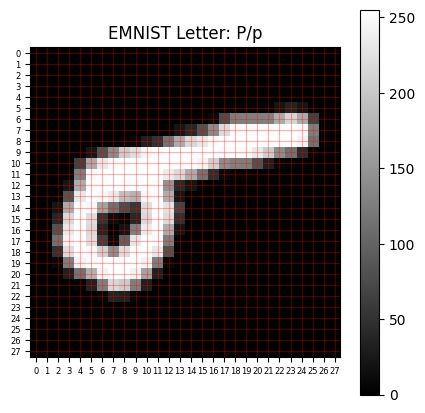


 Image type: <class 'PIL.Image.Image'>


In [ ]:
img, label = train_dataset[index]  # Extract the image and its label

helper_utils.visualize_image(img, label)  # Display the image with its label

# The image is stored as a PIL Image object. We'll convert it to a tensor before training.
print(f"\n Image type: {type(img)}")

We notice that the handwritten letters appear rotated or flipped. Technically, a model can still learn from them as long as **every image is oriented the same way**. The model doesn’t “know” what properly oriented letter looks like; it just learns patterns that are consistent across the dataset.

However, this can make it harder for *us* to visually inspect or interpret the samples.
In the next step, we’ll use a helper function to display the letters in a more familiar orientation so they’re easier to look at. This correction is only for visualization. The underlying data will remain unchanged, and the model will still train on it exactly as provided.

<a name='1.3'></a>
### 1.3 - Preprocessing the Images

Before we can train your model, we need to convert the images into a format that PyTorch can work with, and apply normalization to help the model learn more effectively.

To do this, we’ll use `transforms.Compose` to apply a sequence of preprocessing steps: 
* `transforms.ToTensor()` converts the image from a PIL format to a PyTorch tensor.
* `transforms.Normalize(mean, std)` scales pixel values using precomputed mean and standard deviation values.

Normalization keeps pixel values within a consistent range, which improves numerical stability and helps our model train faster and more reliably.

These transformations are applied automatically **each time a sample is loaded from the dataset**, ensuring that all data passed to the model is standardized and ready for training or evaluation.

In [9]:
# Precomputed mean and std for EMNIST Letters dataset
mean = (0.1736,)
std = (0.3317,)

# Create a transform that converts images to tensors and normalizes them
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts images to PyTorch tensors and scales pixel values to [0, 1]
    transforms.Normalize(mean=mean, std=std)   # Applies normalization using the computed mean and std
])

# Assign the transform to both the training and test datasets
train_dataset.transform = transform
test_dataset.transform = transform

Now let's look at the another sample. 
This time, we’re seeing the raw tensor after the transformations were applied.

In [ ]:
index = 90000  # Pick an index from the training set

In [11]:
# Retrieve the transformed image tensor and its label from the training set
img_tensor, label = train_dataset[index]

# Print the image tensor to see the raw values (after transformation)
print(img_tensor)

tensor([[[-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.4761, -0.4288, -0.4288, -0.5234, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.4879,  0.0323,
           1.8648,  2.0894,  2.0421, -0.1450, -0.5234, -0.5234, -0.5234],
         [-0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234, -0.5234,
          -0.5234, -0.5234, -0.5234, -0.5234, -0

First, each pixel value (originally between 0 and 255) was scaled to a range between 0 and 1. Then, those values were normalized by subtracting the dataset’s average pixel value and dividing by its standard deviation.

That’s why the numbers we see now are centered around 0—some are negative, some positive. These values show how much brighter or darker each pixel is compared to the dataset average. This normalization step helps our model train faster and more reliably.

Now we can visualize one of the transformed images using the `helper_utils.visualize_image` function.

Because the images in this dataset aren’t oriented correctly, we’ll first apply the `correct_image_orientation` function. This function uses transformations like `F.rotate` and `F.vflip` to display the letters in their proper orientation.

This step is **only for visualization**. It helps us interpret the images more easily. The dataset itself remains unchanged, and the model will still train on the original, uncorrected data.

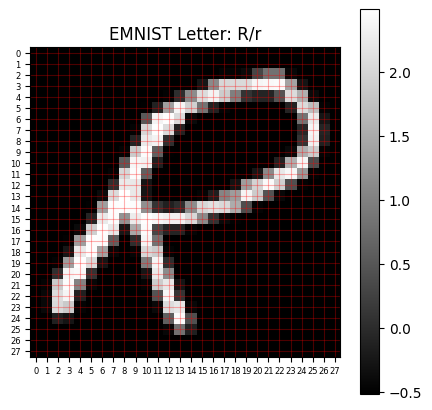

In [12]:
def correct_image_orientation(image):
    rotated = F.rotate(image, 90) # Rotate the image 90 degrees clockwise
    flipped = F.vflip(rotated) # Flip the image vertically
    return flipped

# Rotate the image and Reflect it
img_transformed = correct_image_orientation(img_tensor)

# Visualize the transformed image
helper_utils.visualize_image(img_transformed, label)

<a name='1.4'></a>
### 1.4 - Loading Data in Batches

Our neural network needs input in a structured, consistent format. To achieve that, we’ll use PyTorch’s `DataLoader` to organize our preprocessed letter images into batches—making training more efficient and easier to manage.

In this step, we’ll complete the `create_emnist_dataloaders` to set up `DataLoader` objects for both training and test data. These loaders will automatically handle batching and shuffling, ensuring that our model trains effectively and generalizes well.

<a name='ex1'></a>
### Exercise 1 - create_emnist_dataloaders

Implement the `create_emnist_dataloaders` function to create PyTorch `DataLoader` objects for the EMNIST training and testing datasets.

**Task:**
* Create `train_dataloader` and `test_dataloader` using the `DataLoader` class from `torch.utils.data`. 
    * Define `shuffle` accordingly to each dataset.
    * Use the `batch_size` parameter to set the number of samples per batch.

In [ ]:
def create_emnist_dataloaders(train_dataset, test_dataset, batch_size=64):
    """
    Creates DataLoader objects for the EMNIST training and testing datasets.

    Args:
        train_dataset (torch.utils.data.Dataset): The training dataset.
        test_dataset (torch.utils.data.Dataset): The testing dataset.
        batch_size (int, optional): The batch size for the DataLoaders. Defaults to 64.

    Returns:
        tuple (torch.utils.data.DataLoader, torch.utils.data.DataLoader):
            A tuple containing the training and testing DataLoaders (train_loader, test_loader).
    """

    # Create a DataLoader for the training dataset
    train_dataloader = DataLoader(
        # Pass in the train_dataset
        dataset=train_dataset,
        # Set batch_size
        batch_size=batch_size,
        # Set shuffle
        shuffle=True
    )  

    # Create a DataLoader for the testing dataset
    test_dataloader = DataLoader(
        # Pass in the test_dataset
        dataset=test_dataset,
        # Set batch_size
        batch_size=batch_size,
        # Set shuffle
        shuffle=False
    )  

    # Return the created DataLoaders
    return train_dataloader, test_dataloader

Examine the contents of the resulting `DataLoader` objects. 
This will help us verify that the artifacts have been correctly organized into batches and that the shuffling has been applied to the training data.

In [15]:
train_loader, test_loader = create_emnist_dataloaders(train_dataset, test_dataset, batch_size=64)

print("--- Train Loader --- \n")
helper_utils.display_data_loader_contents(train_loader)
print("\n--- Test Loader --- \n")
helper_utils.display_data_loader_contents(test_loader)

--- Train Loader --- 

Total number of images in dataset: 124800
Total number of batches: 1950
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])

--- Test Loader --- 

Total number of images in dataset: 20800
Total number of batches: 325
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


<a name='2'></a>
## 2 - Building the Neural Network

Now that our data pipeline is ready, it’s time to build our neural network model.

In this step, we’ll define a model that can learn to recognize and classify handwritten letters from the EMNIST dataset. We’ll also set up the loss function and optimizer that the model will use during training.

<a name='ex2'></a>
### Exercise 2 - initialize_emnist_model

Implement the `initialize_emnist_model` function to create a PyTorch `Sequential` model for EMNIST classification.

In [ ]:
def initialize_emnist_model(num_classes=26):
    """
    Initializes a sequential neural network model for EMNIST classification.

    Args:
        num_classes (int): The number of output classes. Defaults to 26.

    Returns:
        tuple: A tuple containing the model, loss function, and optimizer.
               (model, loss_function, optimizer)
    """

    torch.manual_seed(42)  # Set seed for reproducibility

    # Define the neural network model using nn.Sequential
    model = nn.Sequential(
        # Flatten the input images
        nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    )

    # Define the loss function (Cross-Entropy Loss for multi-class classification)
    loss_function = nn.CrossEntropyLoss()

    # Define the optimizer (Adaptive Moment Estimation)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    return model, loss_function, optimizer

Examine the model definition.
This will help us ensure that the model architecture, loss function, and optimizer are correctly configured.

In [24]:
your_model, loss_func, optimizer = initialize_emnist_model(num_classes=26)

print(f"Your model's architecture:\n\n{your_model}\n")
print(f"Your model's loss function: {loss_func}\n")
print(f"Your model's optimizer:\n\n{optimizer}\n")

Your model's architecture:

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=26, bias=True)
)

Your model's loss function: CrossEntropyLoss()

Your model's optimizer:

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)



<a name='3'></a>
## 3 - Training and evaluation of the Model

<a name='3.1'></a>
### 3.1 - Training the Model

The data pipeline is ready, and our model is built. Now it's time for **training**.

This is where all the previous steps come together—allowing our model to learn from the training data.
<a name='ex3'></a>
### Exercise 3 - train_epoch

Implement the `train_epoch` function to train a PyTorch model for one epoch and calculate the average loss and accuracy on the training set.

In [ ]:
def train_epoch(model, loss_function, optimizer, train_loader, device, verbose=True):
    """
    Trains the model for one epoch and calculates the average loss and accuracy.

    Args:
        model (nn.Module): The PyTorch model to be trained.
        loss_function (nn.Module): The loss function used for training.
        optimizer (optim.Optimizer): The optimizer used for updating model parameters.
        train_loader (DataLoader): DataLoader for the training dataset, providing batches of data.
        device (torch.device): The device (CPU or CUDA) where the model and data will be moved.
        verbose (bool, optional): If True, prints the average loss and accuracy for the epoch. Defaults to True.

    Returns:
        tuple: A tuple containing:
            - nn.Module: The trained model after one epoch.
            - float: The average loss for the epoch.
            - float: The accuracy percentage for the epoch.

    Note:
        - The target labels in the `train_loader` (EMNIST letters) are 1-indexed and so the function adjusts them
          to 0-indexed before calculating the loss.
    """

    # Move the model to the specified device (CPU or GPU)
    model.to(device)
    # Set the model to training mode
    model.train()
    # Initialize running loss to 0
    running_loss = 0.0
    # Initialize the number of correct predictions to 0
    num_correct_predictions = 0
    # Initialize the total number of predictions to 0
    total_predictions = 0

    # Iterate over the batches of data from the training DataLoader
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move the inputs and targets to the specified device
        inputs, targets = inputs.to(device), targets.to(device)

        # Shift target labels down by 1 (adjusting for EMNIST letters dataset)
        targets = targets - 1

        # Zero the gradients of the optimizer.
        optimizer.zero_grad()

        # Pass the inputs through the model to get the outputs.
        outputs = model(inputs)

        # Calculate the loss between the outputs and the targets.
        loss = loss_function(outputs, targets)

        # Perform backpropagation to calculate the gradients.
        loss.backward()

        # Update the model parameters using the optimizer.
        optimizer.step()

        # Loss 
        # Accumulate the loss value to running_loss
        loss_value = loss.item()
        # Add current loss value to the total running loss.
        running_loss += loss_value 

        # Accuracy
        # Get the predicted indices (by taking the argmax along dimension 1 of the outputs).
        predicted_indices = outputs.argmax(dim=1)

        # Compare predicted indices to actual targets
        correct_predictions = predicted_indices.eq(targets)

        # Sum of correct predictions in the current batch.
        num_correct_in_batch = correct_predictions.sum().item()
        
        # Add correct predictions to the total correct predictions.
        num_correct_predictions += num_correct_in_batch

        # Get the batch size from the targets and add it to total predictions.
        batch_size = targets.size(0)
        total_predictions += batch_size 


    # Calculate the average loss for the epoch. 
    average_loss = running_loss / len(train_loader)

    # Calculate the accuracy percentage for the epoch. 
    accuracy_percentage = 100 * (num_correct_predictions / total_predictions)

    # Conditionally print based on verbose flag
    if verbose:
        print(
            f"Epoch Loss (Avg): {average_loss:.3f} | Epoch Acc: {accuracy_percentage:.2f}%"
        )

    # Return the trained model and average loss
    return model, average_loss

Observe the model's initial learning process.
We'll execute the function for a single epoch and verify that the model is indeed training as expected.

In [ ]:
model, loss_function, optimizer = initialize_emnist_model(num_classes=26)

model_one_train_epoch, _ = train_epoch(model=model, # model
                                       loss_function=loss_function, # loss_function
                                       optimizer=optimizer, # optimizer
                                       train_loader=train_loader, # train_loader
                                       device=DEVICE) # DEVICE

Epoch Loss (Avg): 0.599 | Epoch Acc: 81.54%


<a name='3.2'></a>
### 3.2 - Evaluation of the Model

After training our model, it’s time to see how well it performs on data it hasn’t seen before. Evaluating on unseen data helps us measure how well the model generalizes to new handwritten samples.

In this step, we’ll implement the `evaluate_model` function to assess our model’s performance on the test dataset. We’ll use **accuracy** as the evaluation metric to quantify how often the model’s predictions match the true labels.

<a name='ex4'></a>
### Exercise 4 - evaluate

Implement the `evaluate` function to evaluate a PyTorch model on a test dataset and calculate the average accuracy.

In [ ]:
def evaluate(model, test_loader, device, verbose=True):
    """
    Evaluates the model on the test dataset and returns the accuracy percentage.

    Args:
        model (nn.Module): The PyTorch model to be evaluated.
        test_loader (DataLoader): DataLoader for the testing dataset.
        device (torch.device): The device to use (CPU or CUDA).
        verbose (bool, optional): If True, prints the test accuracy. Defaults to True.

    Returns:
        float: The accuracy percentage of the model on the test dataset.

    Note:
        - The target labels in the `test_loader` (EMNIST letters) are 1-indexed and so the function adjusts them 
          to 0-indexed before calculating the accuracy.
    """
    
    # Set the model to evaluate mode
    model.eval()
    # Initialize the number of correct predictions to 0
    num_correct_predictions = 0
    # Initialize the total number of predictions to 0
    total_predictions = 0 
    
    with torch.no_grad():        
        # Iterate over the batches of data from the test DataLoader
        for inputs, targets in test_loader:
            # Move the inputs and targets to the specified device
            inputs, targets = inputs.to(device), targets.to(device)

            # Shift target labels down by 1 (adjusting for EMNIST letters dataset)
            targets = targets - 1

            # Pass the inputs through the model to get the outputs.
            outputs = model(inputs)

            # Get the predicted indices (by taking the argmax along dimension 1 of the outputs).
            predicted_indices = outputs.argmax(dim=1)

            # Compare predicted indices to actual targets
            correct_predictions = predicted_indices.eq(targets)        
            
            # Sum of correct predictions in the current batch.
            num_correct_in_batch = correct_predictions.sum().item()
            
            # Add correct predictions to the total correct predictions.
            num_correct_predictions += num_correct_in_batch

            # Get the batch size from the targets and add it to total predictions.
            batch_size = targets.size(0)
            total_predictions += batch_size
        
        # Calculate the accuracy percentage. 
        accuracy_percentage = (num_correct_predictions / total_predictions) * 100

    if verbose:  # Conditionally print based on verbose flag
        print((f'Test Accuracy: {accuracy_percentage:.2f}%'))

    return accuracy_percentage

To verify that our model is working as intended, start by evaluating it on the test dataset. This step confirms that our model has learned meaningful patterns from the training data and that our evaluation function is performing correctly.

In [30]:
model_evaluate = evaluate(model, test_loader, DEVICE)

Test Accuracy: 89.75%


<a name='3.3'></a>
### 3.3 - Putting it all together

Now that we’ve implemented both the training and evaluation functions, it’s time to put everything together.
In this step, we’ll use the previously defined `train_epoch` and `evaluate` functions to create a complete training and evaluation loop.

<a name='ex5'></a>
### Exercise 5 - train_and_evaluate

Implement the `train_and_evaluate` function to train and evaluate a PyTorch model for a specified number of epochs.

In [ ]:
def train_and_evaluate(
    model, train_loader, test_loader, num_epochs, loss_function, optimizer, device
):
    """
    Trains and evaluates the model for the specified number of epochs.

    Args:
        model (nn.Module): The PyTorch model to be trained.
        train_loader (DataLoader): DataLoader for the training dataset.
        test_loader (DataLoader): DataLoader for the testing dataset.
        num_epochs (int): The number of epochs to train for.
        loss_function (nn.Module): The loss function used for training.
        optimizer (optim.Optimizer): The optimizer used for updating model parameters.
        device (torch.device): The device to use (CPU or CUDA).

    Returns:
        nn.Module: The trained model.
    """

    for epoch in range(num_epochs):
        print(f"\nEpoch: {epoch+1}")

        # Train the model for one epoch using the train_epoch function.
        trained_model, _ = train_epoch(model, loss_function, optimizer, train_loader, device)

        # Evaluate the trained model on the test dataset using the evaluate function.
        accuracy = evaluate(model, test_loader, device)

    return trained_model

#### Train Our Model

That is it! We have successfully implemented the training and evaluation functions for our model. It is now time to train our model on the EMNIST dataset and evaluate its performance.

In [ ]:
# Set the number of training epochs. 
num_epochs = 10

In [ ]:
if num_epochs > 15 or num_epochs < 1:
    print(f"\033[91mSet num_epochs between 1 and 15 (inclusive).")

else:
    # Initialize the EMNIST model, loss function, and optimizer
    emnist_model, loss_function, optimizer = initialize_emnist_model(num_classes=26)
    
    # Train and evaluate the model for the specified number of epochs
    trained_model = train_and_evaluate(
        model=emnist_model,
        train_loader=train_loader,
        test_loader=test_loader,
        num_epochs=num_epochs,
        loss_function=loss_function,
        optimizer=optimizer,
        device=DEVICE
    )


Epoch: 1
Epoch Loss (Avg): 0.599 | Epoch Acc: 81.54%
Test Accuracy: 87.40%

Epoch: 2
Epoch Loss (Avg): 0.327 | Epoch Acc: 89.40%
Test Accuracy: 89.64%

Epoch: 3
Epoch Loss (Avg): 0.272 | Epoch Acc: 90.91%
Test Accuracy: 90.02%

Epoch: 4
Epoch Loss (Avg): 0.240 | Epoch Acc: 91.86%
Test Accuracy: 90.09%

Epoch: 5
Epoch Loss (Avg): 0.217 | Epoch Acc: 92.49%
Test Accuracy: 90.57%

Epoch: 6
Epoch Loss (Avg): 0.196 | Epoch Acc: 93.02%
Test Accuracy: 90.69%

Epoch: 7
Epoch Loss (Avg): 0.181 | Epoch Acc: 93.50%
Test Accuracy: 90.41%

Epoch: 8
Epoch Loss (Avg): 0.168 | Epoch Acc: 93.85%
Test Accuracy: 90.42%

Epoch: 9
Epoch Loss (Avg): 0.159 | Epoch Acc: 94.12%
Test Accuracy: 90.17%

Epoch: 10
Epoch Loss (Avg): 0.148 | Epoch Acc: 94.51%
Test Accuracy: 90.12%


After training, it's time to evaluate its performance on the test dataset.
We'll evaluate its accuracy *on each individual letter class* to identify any potential strengths or weaknesses in its analysis.

In [38]:
# Evaluate the trained model's performance on each letter class
class_accuracies = helper_utils.evaluate_per_class(trained_model, test_loader, DEVICE)

# Print the accuracy for each letter class
for letter, accuracy in class_accuracies.items():
    print(f"Accuracy for {letter}: {(accuracy*100):.2f} %")

Accuracy for A: 88.25 %
Accuracy for B: 92.25 %
Accuracy for C: 90.50 %
Accuracy for D: 92.75 %
Accuracy for E: 94.12 %
Accuracy for F: 94.62 %
Accuracy for G: 74.88 %
Accuracy for H: 91.38 %
Accuracy for I: 80.50 %
Accuracy for J: 94.12 %
Accuracy for K: 86.62 %
Accuracy for L: 62.12 %
Accuracy for M: 96.12 %
Accuracy for N: 94.00 %
Accuracy for O: 97.12 %
Accuracy for P: 91.25 %
Accuracy for Q: 81.75 %
Accuracy for R: 92.12 %
Accuracy for S: 95.00 %
Accuracy for T: 93.12 %
Accuracy for U: 93.62 %
Accuracy for V: 89.00 %
Accuracy for W: 95.62 %
Accuracy for X: 96.00 %
Accuracy for Y: 89.50 %
Accuracy for Z: 96.88 %


 #### Save our Trained Model

In [ ]:
helper_utils.save_student_model(model=trained_model, filename='trained_student_model.pth')

Model saved to trained_student_model.pth


<a name='conclusion'></a>
## Conclusion

We’ve built our own letter-recognizing neural network!

We’ve worked through every key stage of the deep learning workflow. We began by acquiring and preprocessing the EMNIST “Letters” dataset, calculating its mean and standard deviation, correcting image orientations, and normalizing pixel values. We then organized our data efficiently using PyTorch DataLoaders.

Next, we designed and initialized a multi-layer neural network, selected an appropriate loss function and optimizer, and brought our model to life by implementing the training and evaluation loops. We watched its performance improve over epochs and finally put it to the test.